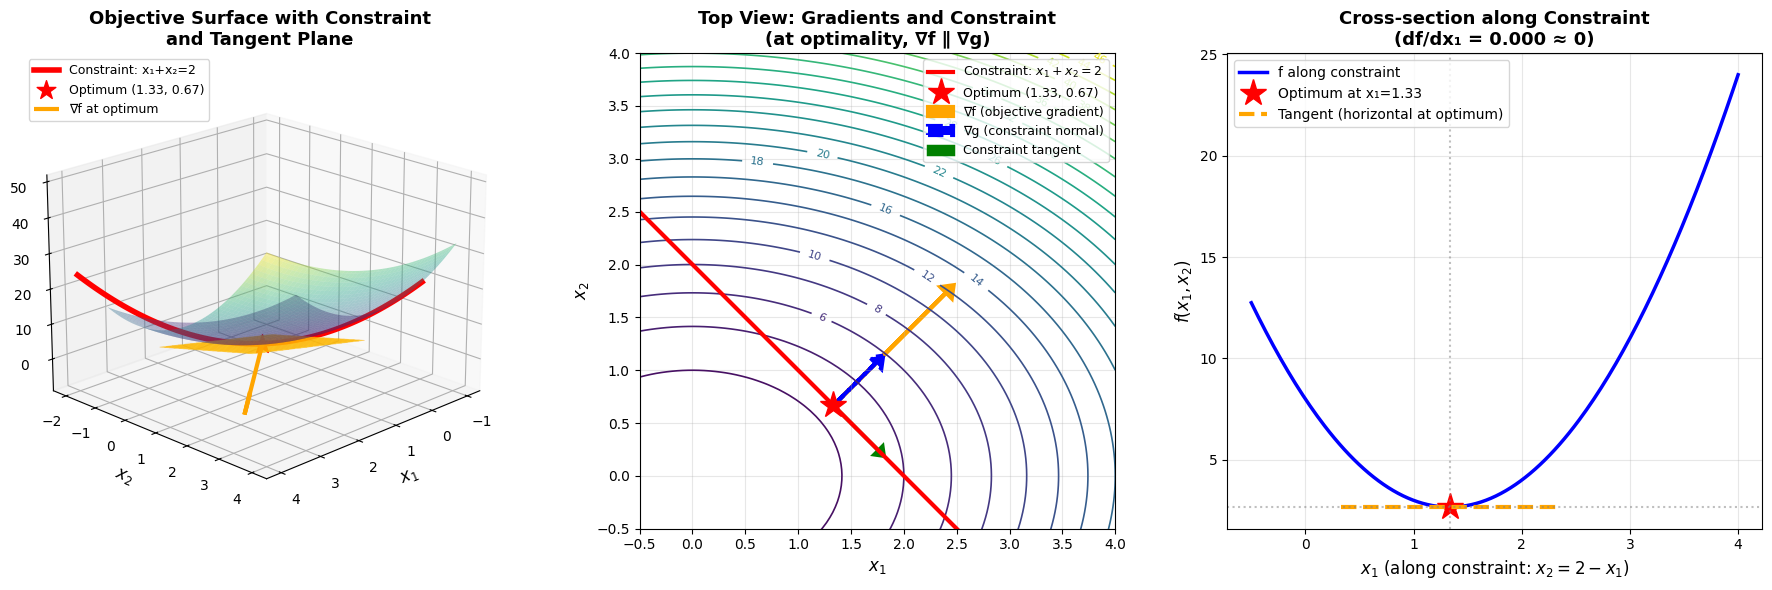

CONSTRAINED OPTIMIZATION ANALYSIS

Problem:
  minimize f(x₁, x₂) = x₁² + 2x₂²
  subject to g(x₁, x₂) = x₁ + x₂ - 2 = 0

Optimal Solution:
  x₁* = 1.3333
  x₂* = 0.6667
  f* = 2.6667

Gradients at Optimum:
  ∇f = [2.6667, 2.6667]
  ∇g = [1, 1]

Lagrange Multiplier λ:
  ∇f = λ∇g
  λ = 2.6667
  Verification: ∇f/∇g = [2.6667, 2.6667]

Geometric Interpretation:
  • The tangent plane to f is TILTED at the optimal point
  • Along the constraint direction, the tangent is HORIZONTAL
  • This means: moving along the constraint from optimum,
    the function value initially doesn't change (to first order)
  • The gradient ∇f is perpendicular to the constraint line
  • This is the Lagrange multiplier optimality condition!





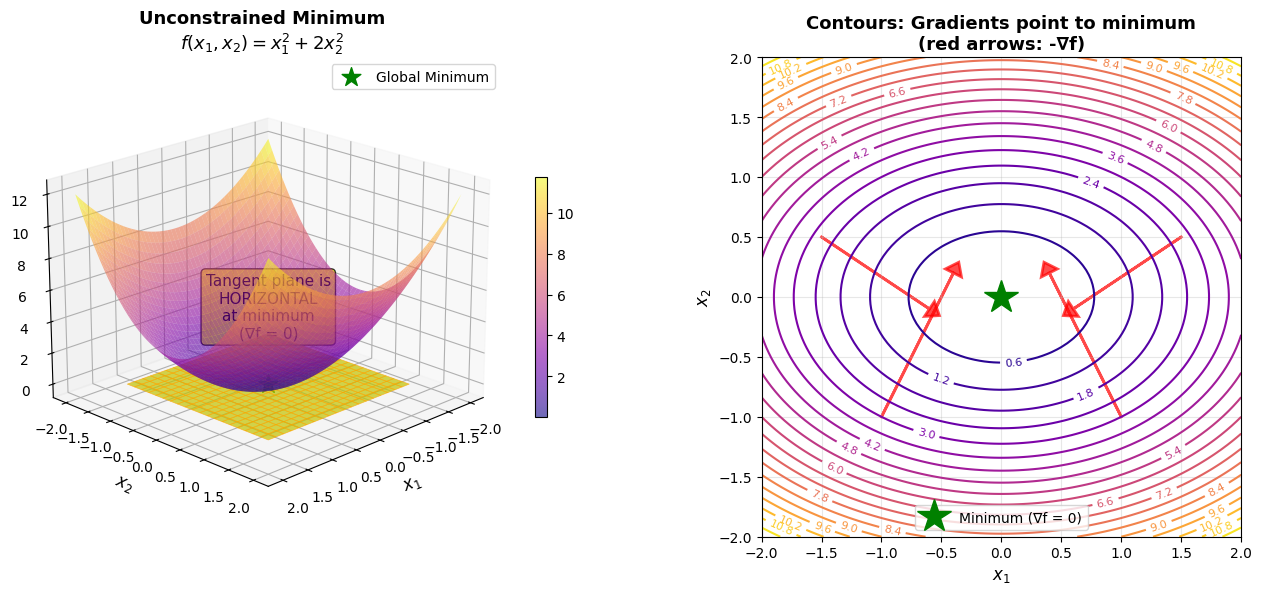


UNCONSTRAINED OPTIMIZATION
minimize f(x₁, x₂) = x₁² + 2x₂²

Optimality Condition: ∇f = 0
  ∂f/∂x₁ = 2x₁ = 0  →  x₁* = 0
  ∂f/∂x₂ = 4x₂ = 0  →  x₂* = 0

At the minimum:
  • Gradient is zero: ∇f = [0, 0]
  • Tangent plane is HORIZONTAL (slope = 0 in all directions)
  • Function value cannot decrease in any direction


In [2]:
import numpy as np
import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# from matplotlib import cm

def visualize_constrained_optimization():
    """
    Visualize a constrained optimization problem:
    minimize f(x1, x2) = x1² + 2*x2²
    subject to x1 + x2 = 2 (a linear constraint)
    
    At the optimal point, the gradient of f is perpendicular to the constraint,
    and the tangent plane to f is horizontal in the constraint direction.
    """
    fig = plt.figure(figsize=(18, 6))
    
    # Create grid
    x1 = np.linspace(-1, 4, 100)
    x2 = np.linspace(-1, 4, 100)
    X1, X2 = np.meshgrid(x1, x2)
    
    # Objective function: f(x1, x2) = x1² + 2*x2²
    Z = X1**2 + 2*X2**2
    
    # Constraint: x1 + x2 = 2, so x2 = 2 - x1
    x1_constraint = np.linspace(-1, 4, 100)
    x2_constraint = 2 - x1_constraint
    z_constraint = x1_constraint**2 + 2*x2_constraint**2
    
    # Find optimal point on constraint
    # Using Lagrange multipliers or substitution:
    # Substitute x2 = 2 - x1 into f:
    # f(x1) = x1² + 2(2-x1)² = x1² + 2(4 - 4x1 + x1²) = 3x1² - 8x1 + 8
    # df/dx1 = 6x1 - 8 = 0 => x1* = 4/3
    x1_opt = 4/3
    x2_opt = 2 - x1_opt  # = 2/3
    z_opt = x1_opt**2 + 2*x2_opt**2
    
    # Gradient at optimal point: ∇f = [2*x1, 4*x2]
    grad_opt = np.array([2*x1_opt, 4*x2_opt])
    
    # Constraint gradient (normal to constraint line): ∇g = [1, 1]
    constraint_normal = np.array([1, 1])
    
    # ========== Plot 1: 3D Surface with Constraint ==========
    ax1 = fig.add_subplot(131, projection='3d')
    
    # Plot the objective surface
    surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.4, 
                            edgecolor='none', antialiased=True)
    
    # Plot the constraint line in 3D (on the surface)
    ax1.plot(x1_constraint, x2_constraint, z_constraint, 
            'r-', linewidth=4, label='Constraint: x₁+x₂=2')
    
    # Mark the optimal point
    ax1.scatter([x1_opt], [x2_opt], [z_opt], color='red', s=200, 
               marker='*', zorder=10, label=f'Optimum ({x1_opt:.2f}, {x2_opt:.2f})')
    
    # Plot gradient at optimal point
    scale = 0.8
    ax1.quiver(x1_opt, x2_opt, z_opt,
              grad_opt[0], grad_opt[1], 0,
              color='orange', arrow_length_ratio=0.3, linewidth=3,
              label='∇f at optimum')
    
    # Create tangent plane at optimal point
    # The tangent plane is: z - z_opt = ∇f · (x - x_opt)
    # z = z_opt + grad_opt[0]*(x1 - x1_opt) + grad_opt[1]*(x2 - x2_opt)
    x1_plane = np.linspace(x1_opt - 1.5, x1_opt + 1.5, 20)
    x2_plane = np.linspace(x2_opt - 1.5, x2_opt + 1.5, 20)
    X1_plane, X2_plane = np.meshgrid(x1_plane, x2_plane)
    Z_plane = z_opt + grad_opt[0]*(X1_plane - x1_opt) + grad_opt[1]*(X2_plane - x2_opt)
    
    ax1.plot_surface(X1_plane, X2_plane, Z_plane, alpha=0.5, 
                    color='yellow', edgecolor='orange', linewidth=0.5)
    
    ax1.set_xlabel('$x_1$', fontsize=12)
    ax1.set_ylabel('$x_2$', fontsize=12)
    ax1.set_zlabel('$f(x_1, x_2)$', fontsize=12)
    ax1.set_title('Objective Surface with Constraint\nand Tangent Plane', 
                  fontsize=13, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.view_init(elev=20, azim=45)
    
    # ========== Plot 2: Top View (Contours) ==========
    ax2 = fig.add_subplot(132)
    
    # Plot contours
    contour = ax2.contour(X1, X2, Z, levels=25, cmap='viridis', linewidths=1.2)
    ax2.clabel(contour, inline=True, fontsize=8)
    
    # Plot constraint line
    ax2.plot(x1_constraint, x2_constraint, 'r-', linewidth=3, 
            label='Constraint: $x_1+x_2=2$')
    
    # Mark optimal point
    ax2.plot(x1_opt, x2_opt, 'r*', markersize=20, 
            label=f'Optimum ({x1_opt:.2f}, {x2_opt:.2f})')
    
    # Plot gradient of objective at optimum
    scale = 0.4
    ax2.arrow(x1_opt, x2_opt, grad_opt[0]*scale, grad_opt[1]*scale,
             head_width=0.15, head_length=0.1, fc='orange', ec='orange', 
             linewidth=3, label='∇f (objective gradient)')
    
    # Plot normal to constraint
    scale = 0.4
    ax2.arrow(x1_opt, x2_opt, constraint_normal[0]*scale, constraint_normal[1]*scale,
             head_width=0.15, head_length=0.1, fc='blue', ec='blue', 
             linewidth=3, label='∇g (constraint normal)', linestyle='--')
    
    # Plot tangent to constraint (perpendicular to normal)
    constraint_tangent = np.array([1, -1]) / np.sqrt(2)  # Normalized
    scale = 0.6
    ax2.arrow(x1_opt, x2_opt, constraint_tangent[0]*scale, constraint_tangent[1]*scale,
             head_width=0.12, head_length=0.08, fc='green', ec='green', 
             linewidth=2.5, label='Constraint tangent')
    
    ax2.set_xlabel('$x_1$', fontsize=12)
    ax2.set_ylabel('$x_2$', fontsize=12)
    ax2.set_title('Top View: Gradients and Constraint\n(at optimality, ∇f ∥ ∇g)', 
                  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.set_xlim(-0.5, 4)
    ax2.set_ylim(-0.5, 4)
    
    # ========== Plot 3: Cross-section along constraint ==========
    ax3 = fig.add_subplot(133)
    
    # Parametric representation along constraint
    # x1 = t, x2 = 2 - t, f(t) = t² + 2(2-t)² = 3t² - 8t + 8
    t = np.linspace(-0.5, 4, 200)
    f_t = 3*t**2 - 8*t + 8
    
    ax3.plot(t, f_t, 'b-', linewidth=2.5, label='f along constraint')
    
    # Mark the optimal point
    f_opt = 3*x1_opt**2 - 8*x1_opt + 8
    ax3.plot(x1_opt, f_opt, 'r*', markersize=20, 
            label=f'Optimum at x₁={x1_opt:.2f}')
    
    # Draw tangent line at optimum (horizontal since derivative = 0)
    tangent_x = np.linspace(x1_opt - 1, x1_opt + 1, 50)
    tangent_y = np.ones_like(tangent_x) * f_opt
    ax3.plot(tangent_x, tangent_y, 'orange', linewidth=3, linestyle='--',
            label='Tangent (horizontal at optimum)')
    
    # Show derivative
    # df/dt = 6t - 8
    df_dt = 6*x1_opt - 8  # Should be 0 at optimum
    
    ax3.set_xlabel('$x_1$ (along constraint: $x_2 = 2 - x_1$)', fontsize=12)
    ax3.set_ylabel('$f(x_1, x_2)$', fontsize=12)
    ax3.set_title(f'Cross-section along Constraint\n(df/dx₁ = {df_dt:.3f} ≈ 0)', 
                  fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=10)
    ax3.axhline(f_opt, color='gray', linestyle=':', alpha=0.5)
    ax3.axvline(x1_opt, color='gray', linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('optimization_tangent_plane.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print analysis
    print("CONSTRAINED OPTIMIZATION ANALYSIS")
    print("=" * 70)
    print(f"\nProblem:")
    print(f"  minimize f(x₁, x₂) = x₁² + 2x₂²")
    print(f"  subject to g(x₁, x₂) = x₁ + x₂ - 2 = 0")
    
    print(f"\nOptimal Solution:")
    print(f"  x₁* = {x1_opt:.4f}")
    print(f"  x₂* = {x2_opt:.4f}")
    print(f"  f* = {z_opt:.4f}")
    
    print(f"\nGradients at Optimum:")
    print(f"  ∇f = [{grad_opt[0]:.4f}, {grad_opt[1]:.4f}]")
    print(f"  ∇g = [{constraint_normal[0]}, {constraint_normal[1]}]")
    
    # Check if gradients are parallel (Lagrange multiplier condition)
    lambda_multiplier = grad_opt[0] / constraint_normal[0]
    print(f"\nLagrange Multiplier λ:")
    print(f"  ∇f = λ∇g")
    print(f"  λ = {lambda_multiplier:.4f}")
    print(f"  Verification: ∇f/∇g = [{grad_opt[0]/constraint_normal[0]:.4f}, {grad_opt[1]/constraint_normal[1]:.4f}]")
    
    print(f"\nGeometric Interpretation:")
    print(f"  • The tangent plane to f is TILTED at the optimal point")
    print(f"  • Along the constraint direction, the tangent is HORIZONTAL")
    print(f"  • This means: moving along the constraint from optimum,")
    print(f"    the function value initially doesn't change (to first order)")
    print(f"  • The gradient ∇f is perpendicular to the constraint line")
    print(f"  • This is the Lagrange multiplier optimality condition!")
    
    print("=" * 70)

def visualize_unconstrained_minimum():
    """
    Visualize unconstrained optimization showing horizontal tangent plane
    """
    fig = plt.figure(figsize=(14, 6))
    
    # Create grid
    x1 = np.linspace(-2, 2, 100)
    x2 = np.linspace(-2, 2, 100)
    X1, X2 = np.meshgrid(x1, x2)
    
    # Objective function: f(x1, x2) = x1² + 2*x2²
    Z = X1**2 + 2*X2**2
    
    # Minimum at origin
    x1_min, x2_min, z_min = 0, 0, 0
    
    # ========== Plot 1: 3D Surface ==========
    ax1 = fig.add_subplot(121, projection='3d')
    
    # Plot the objective surface
    surf = ax1.plot_surface(X1, X2, Z, cmap='plasma', alpha=0.6, 
                            edgecolor='none', antialiased=True)
    
    # Mark the minimum
    ax1.scatter([x1_min], [x2_min], [z_min], color='green', s=200, 
               marker='*', zorder=10, label='Global Minimum')
    
    # Create horizontal tangent plane at minimum
    x1_plane = np.linspace(-1.5, 1.5, 20)
    x2_plane = np.linspace(-1.5, 1.5, 20)
    X1_plane, X2_plane = np.meshgrid(x1_plane, x2_plane)
    Z_plane = np.zeros_like(X1_plane)  # Horizontal plane at z=0
    
    ax1.plot_surface(X1_plane, X2_plane, Z_plane, alpha=0.7, 
                    color='yellow', edgecolor='orange', linewidth=0.5)
    
    # Add text annotation
    ax1.text(0, 0, 3, 'Tangent plane is\nHORIZONTAL\nat minimum\n(∇f = 0)', 
            fontsize=11, ha='center', 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    
    ax1.set_xlabel('$x_1$', fontsize=12)
    ax1.set_ylabel('$x_2$', fontsize=12)
    ax1.set_zlabel('$f(x_1, x_2)$', fontsize=12)
    ax1.set_title('Unconstrained Minimum\n$f(x_1, x_2) = x_1^2 + 2x_2^2$', 
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.view_init(elev=20, azim=45)
    fig.colorbar(surf, ax=ax1, shrink=0.5)
    
    # ========== Plot 2: Contours ==========
    ax2 = fig.add_subplot(122)
    
    contour = ax2.contour(X1, X2, Z, levels=20, cmap='plasma', linewidths=1.5)
    ax2.clabel(contour, inline=True, fontsize=8)
    
    # Mark minimum
    ax2.plot(0, 0, 'g*', markersize=25, label='Minimum (∇f = 0)')
    
    # Draw gradient arrows at several points
    points = [(1.5, 0.5), (-1.5, 0.5), (1, -1), (-1, -1)]
    for pt in points:
        x1_pt, x2_pt = pt
        grad = np.array([2*x1_pt, 4*x2_pt])
        scale = 0.3
        ax2.arrow(x1_pt, x2_pt, -grad[0]*scale, -grad[1]*scale,
                 head_width=0.15, head_length=0.1, fc='red', ec='red', 
                 linewidth=2, alpha=0.7)
    
    ax2.set_xlabel('$x_1$', fontsize=12)
    ax2.set_ylabel('$x_2$', fontsize=12)
    ax2.set_title('Contours: Gradients point to minimum\n(red arrows: -∇f)', 
                  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.savefig('unconstrained_minimum.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nUNCONSTRAINED OPTIMIZATION")
    print("=" * 70)
    print("minimize f(x₁, x₂) = x₁² + 2x₂²")
    print("\nOptimality Condition: ∇f = 0")
    print("  ∂f/∂x₁ = 2x₁ = 0  →  x₁* = 0")
    print("  ∂f/∂x₂ = 4x₂ = 0  →  x₂* = 0")
    print("\nAt the minimum:")
    print("  • Gradient is zero: ∇f = [0, 0]")
    print("  • Tangent plane is HORIZONTAL (slope = 0 in all directions)")
    print("  • Function value cannot decrease in any direction")
    print("=" * 70)

# Run both visualizations
if __name__ == "__main__":
    visualize_constrained_optimization()
    print("\n\n")
    visualize_unconstrained_minimum()